# Image Enhancement Experiments

This notebook demonstrates the preprocessing stages applied to Ottoman document images.

The pipeline includes:

1. Original image
2. Perspective correction
3. Deskewing
4. Grayscale conversion
5. CLAHE contrast enhancement
6. Otsu thresholding
7. Adaptive thresholding
8. Final preprocessing output

In [7]:
from pathlib import Path
import sys

import cv2
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parents[1]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.image_enhancement.deskew import deskew_image
from src.image_enhancement.enhance import (
    apply_clahe,
    convert_to_grayscale,
)
from src.image_enhancement.perspective import correct_perspective
from src.image_enhancement.preprocess import preprocess_image
from src.image_enhancement.threshold import (
    apply_adaptive_threshold,
    apply_otsu_threshold,
)
from src.image_enhancement.utils import read_image

In [8]:
INPUT_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "ground_truth"
    / "sample_01.png"
)

print("Input path:", INPUT_PATH)
print("Path exists:", INPUT_PATH.exists())

image = read_image(INPUT_PATH)

print("Input shape:", image.shape)

Input path: c:\osmanlıca_ceviri\Osmanl-caCeviri\data\raw\ground_truth\sample_01.png
Path exists: True
Input shape: (721, 496, 3)


In [9]:
perspective_corrected = correct_perspective(image)
deskewed = deskew_image(perspective_corrected)
grayscale = convert_to_grayscale(deskewed)
clahe = apply_clahe(grayscale)
otsu = apply_otsu_threshold(clahe)
adaptive = apply_adaptive_threshold(clahe)
final_output = preprocess_image(image)

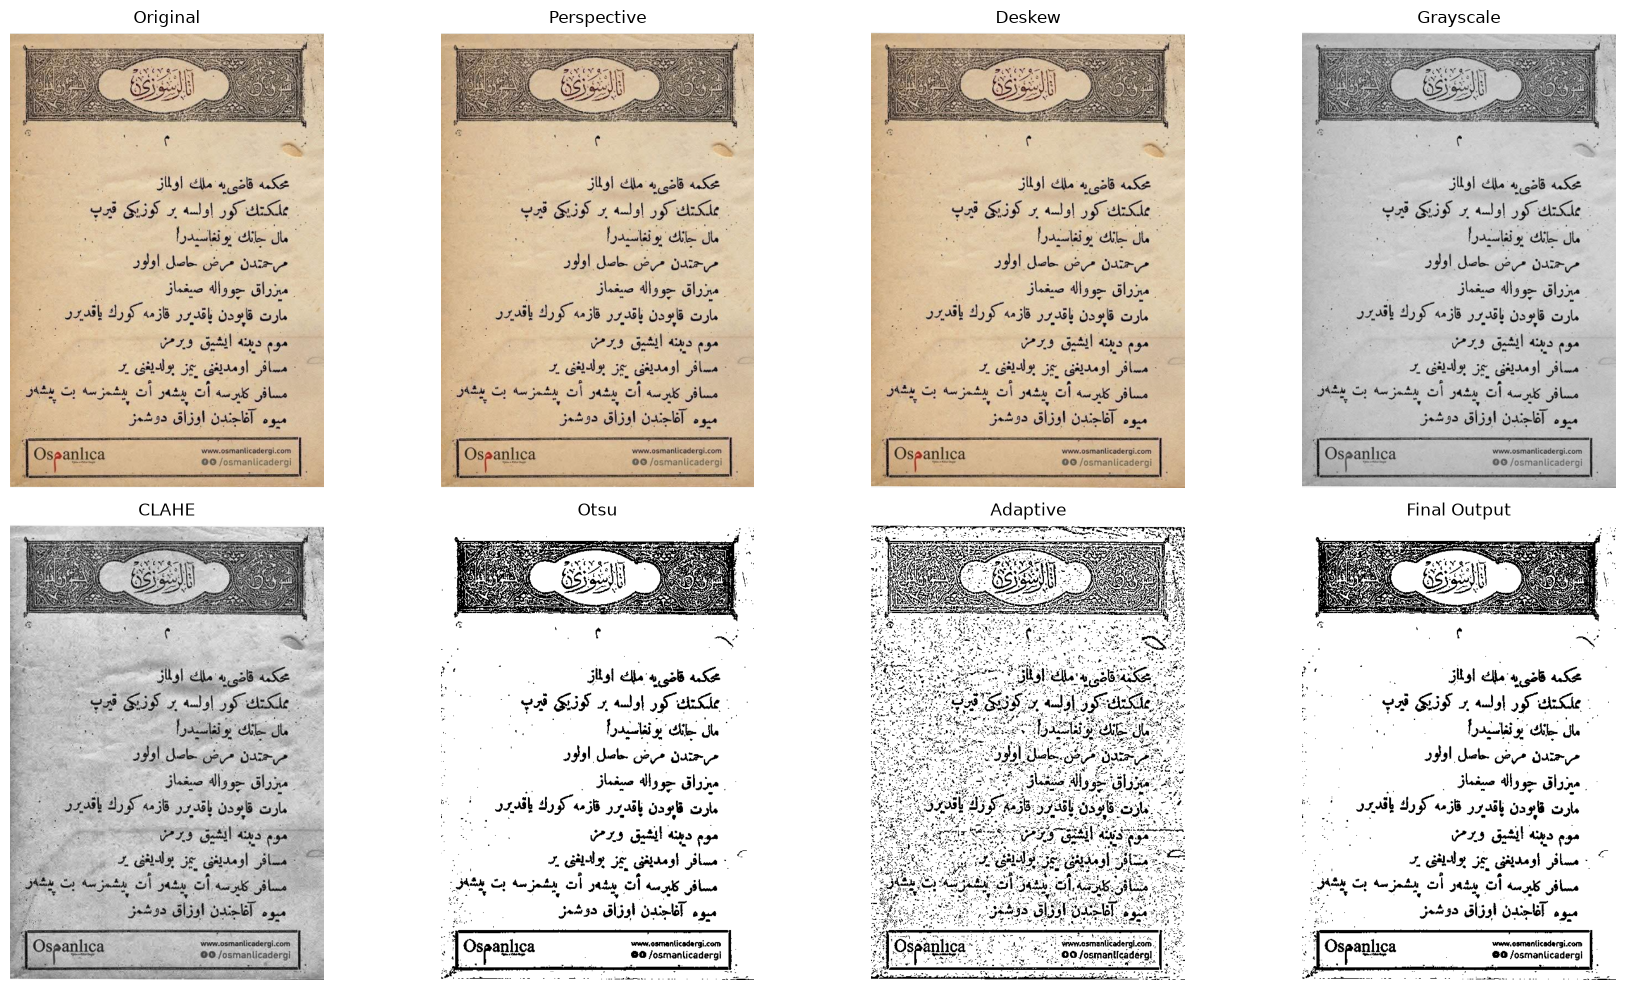

In [10]:
stages = [
    ("Original", cv2.cvtColor(image, cv2.COLOR_BGR2RGB)),
    (
        "Perspective",
        cv2.cvtColor(
            perspective_corrected,
            cv2.COLOR_BGR2RGB,
        ),
    ),
    (
        "Deskew",
        cv2.cvtColor(
            deskewed,
            cv2.COLOR_BGR2RGB,
        ),
    ),
    ("Grayscale", grayscale),
    ("CLAHE", clahe),
    ("Otsu", otsu),
    ("Adaptive", adaptive),
    ("Final Output", final_output),
]

plt.figure(figsize=(18, 10))

for index, (title, stage_image) in enumerate(
    stages,
    start=1,
):
    plt.subplot(2, 4, index)

    if stage_image.ndim == 2:
        plt.imshow(stage_image, cmap="gray")
    else:
        plt.imshow(stage_image)

    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Observations

- Perspective correction attempts to align the document boundaries.
- Deskewing corrects the dominant text-line angle.
- CLAHE improves local contrast and makes faint characters more visible.
- Otsu thresholding generally produces cleaner results on the tested samples.
- Adaptive thresholding may preserve local details but can also amplify paper texture and noise.

In [11]:
def run_image_enhancement_experiment(
    input_path: Path,
) -> None:
    """Run and visualize all image enhancement stages."""
    image = read_image(input_path)

    perspective_corrected = correct_perspective(image)
    deskewed = deskew_image(perspective_corrected)
    grayscale = convert_to_grayscale(deskewed)
    clahe = apply_clahe(grayscale)
    otsu = apply_otsu_threshold(clahe)
    adaptive = apply_adaptive_threshold(clahe)
    final_output = preprocess_image(image)

    stages = [
        ("Original", cv2.cvtColor(image, cv2.COLOR_BGR2RGB)),
        (
            "Perspective",
            cv2.cvtColor(
                perspective_corrected,
                cv2.COLOR_BGR2RGB,
            ),
        ),
        (
            "Deskew",
            cv2.cvtColor(
                deskewed,
                cv2.COLOR_BGR2RGB,
            ),
        ),
        ("Grayscale", grayscale),
        ("CLAHE", clahe),
        ("Otsu", otsu),
        ("Adaptive", adaptive),
        ("Final Output", final_output),
    ]

    plt.figure(figsize=(18, 10))

    for index, (title, stage_image) in enumerate(
        stages,
        start=1,
    ):
        plt.subplot(2, 4, index)

        if stage_image.ndim == 2:
            plt.imshow(stage_image, cmap="gray")
        else:
            plt.imshow(stage_image)

        plt.title(title)
        plt.axis("off")

    plt.suptitle(input_path.name)
    plt.tight_layout()
    plt.show()

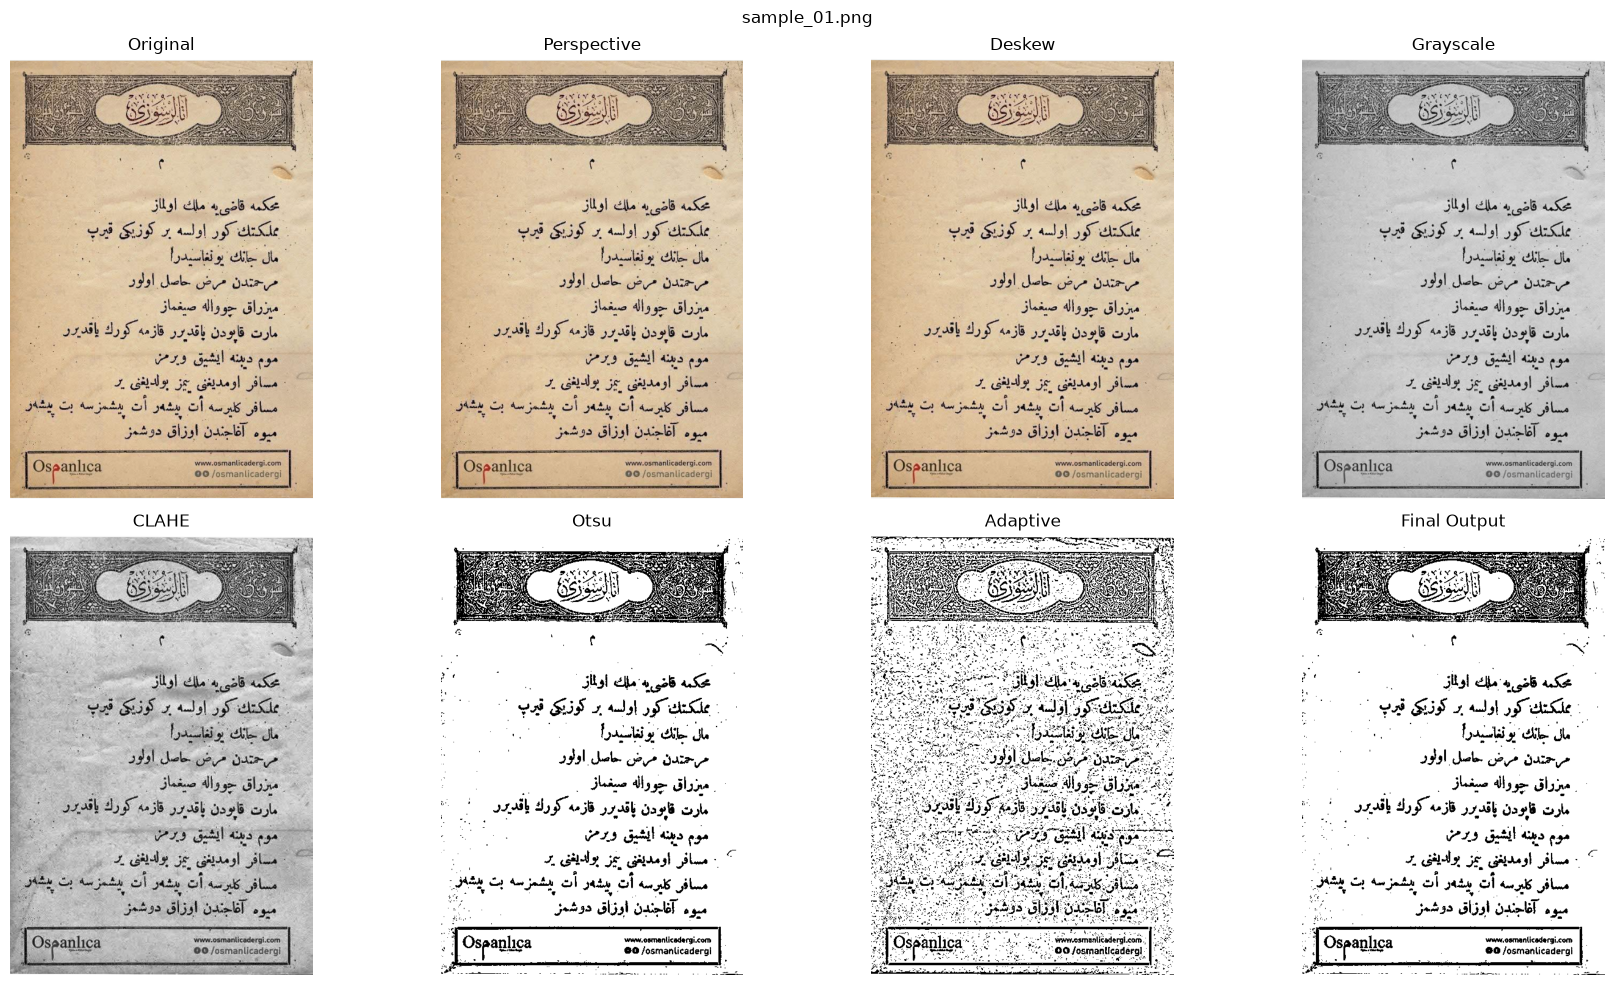

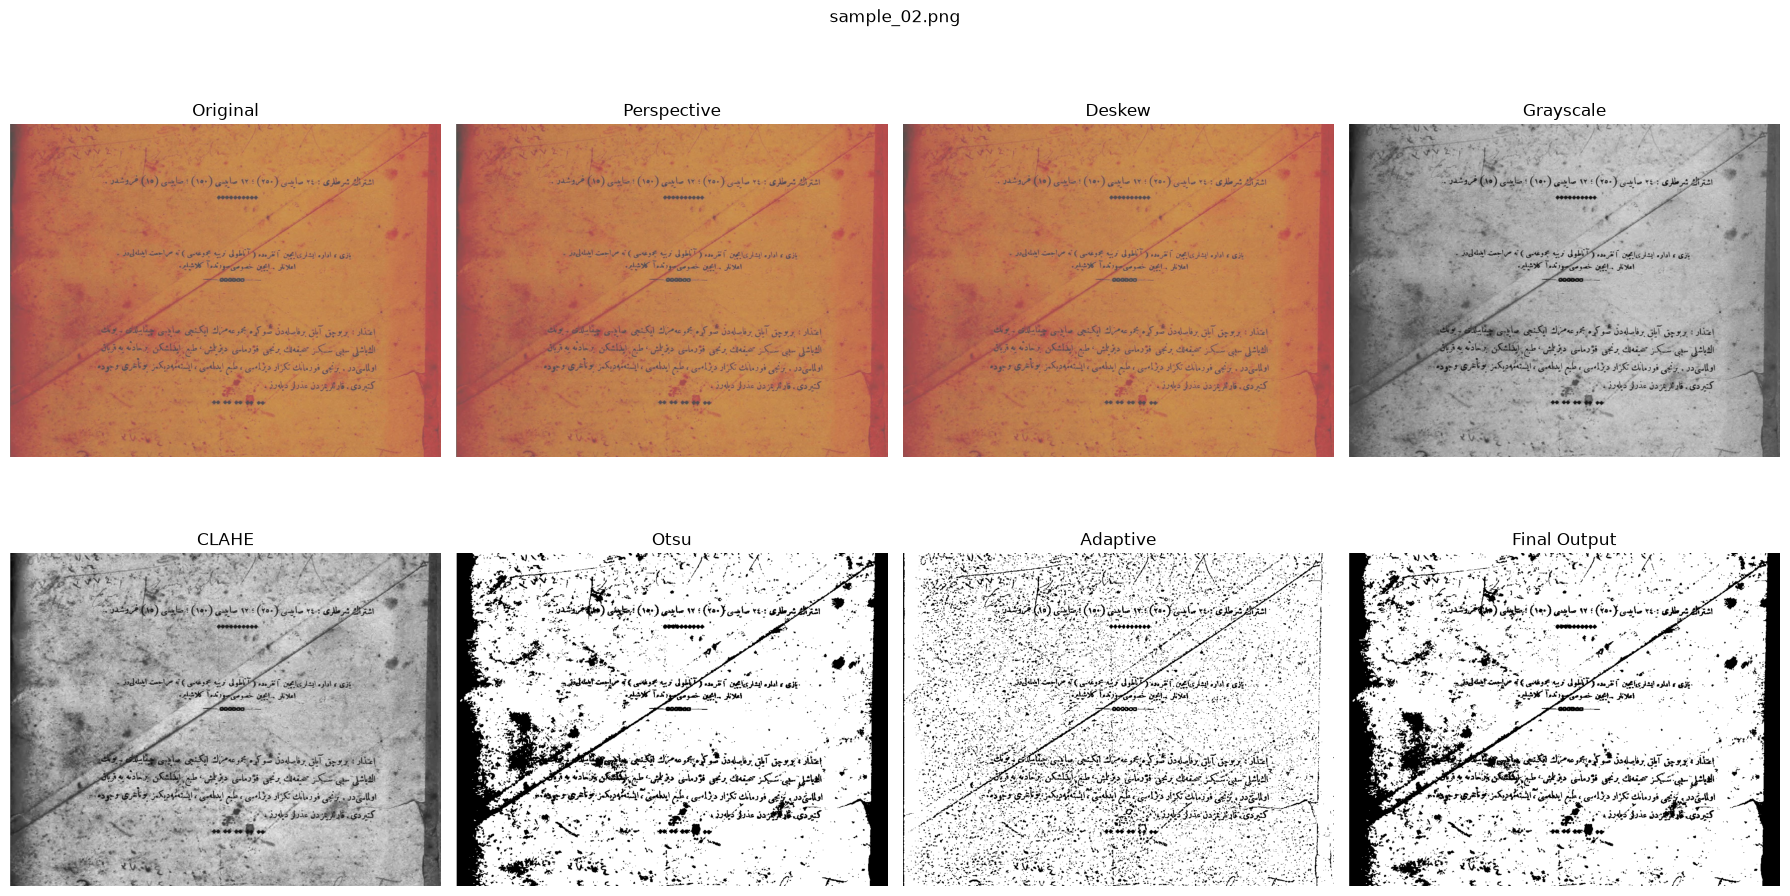

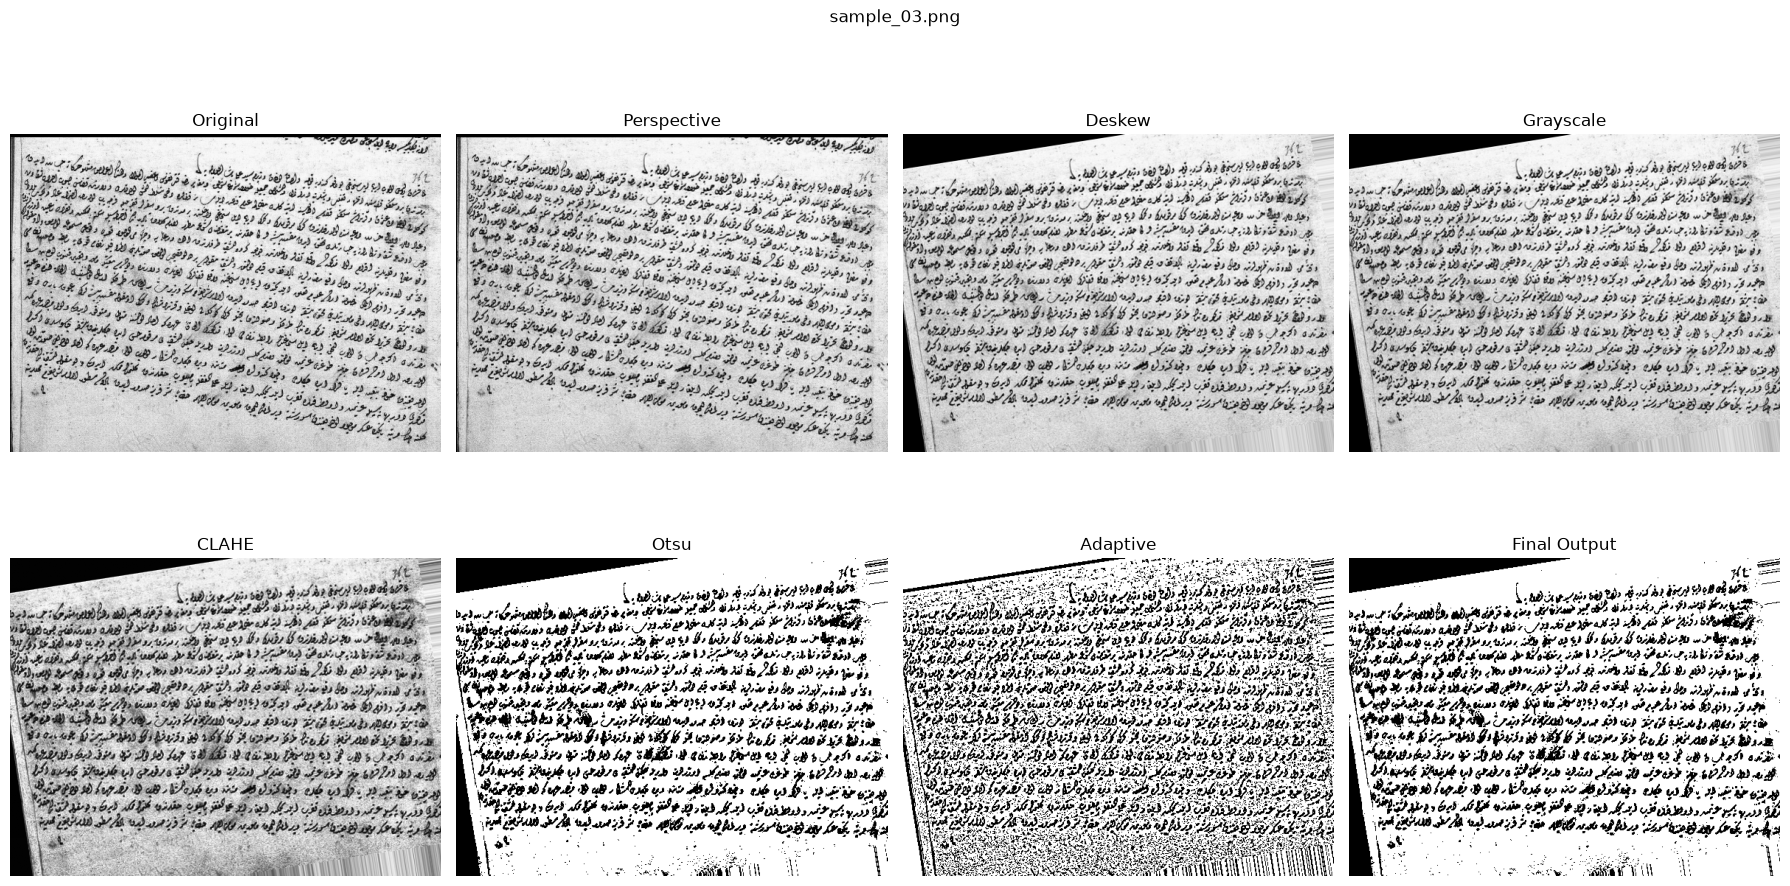

In [12]:
SAMPLE_PATHS = [
    PROJECT_ROOT
    / "data"
    / "raw"
    / "ground_truth"
    / "sample_01.png",

    PROJECT_ROOT
    / "data"
    / "raw"
    / "ground_truth"
    / "sample_02.png",

    PROJECT_ROOT
    / "data"
    / "raw"
    / "ground_truth"
    / "sample_03.png",
]

for sample_path in SAMPLE_PATHS:
    run_image_enhancement_experiment(
        sample_path
    )